In [1]:
import muon as mu
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scib.metrics
from scib.metrics.lisi import recompute_knn, lisi_graph_py
import scanpy as sc
sc.settings.n_jobs = 4  # or however many cores you want

mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

/home/pimanda/julie/miniconda3/envs/scib-env/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
adata = mu.read_h5ad('../Data/GEO_data_file_v1.h5mu', mod = 'rna')

In [3]:
shared = ["2","8","17","21","5","16","12","1","11","24"]

In [4]:
#make subsets
ad = adata.copy()
ad_shared = ad[ad.obs['leiden'].isin(shared)].copy()

In [19]:
ls = {'ad': 'dotted',
        'ad_shared': 'solid'}

lc = {'ad': 'k',
        'ad_shared': 'k'}

Task was destroyed but it is pending!
task: <Task pending name='Task-217' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/pimanda/julie/miniconda3/envs/scib-env/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-218' coro=<Kernel.shell_main() running at /home/pimanda/julie/miniconda3/envs/scib-env/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/pimanda/julie/miniconda3/envs/scib-env/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/pimanda/julie/miniconda3/envs/scib-env/lib/python3.11/tokenize.py:529: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  pseudomatch = _compile(PseudoToken).match(line, pos)
Task was destroyed but it is pending!
task: <Task pending name='Task-218' coro=<Kernel.shell_main() running at /home/pimanda/julie/miniconda3/envs/scib-env/lib/python3.11/site-packages/ipykernel/kernelb

ad time
total cells: 38231
connected cells: 38231
isolated cells removed: 0
auto calculated score =  0.3119169506731046
median unscaled: 1.9357508520193139
median scaled: 0.3119169506731046
ad_shared time
total cells: 16018
connected cells: 16018
isolated cells removed: 0
auto calculated score =  0.3675699328679823
median unscaled: 2.102709798603947
median scaled: 0.36756993286798234


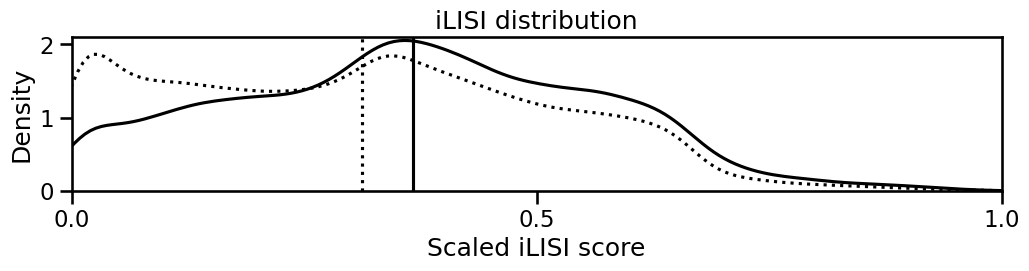

In [21]:
#Make per cell distribution graphs of iLISI score per cell for each metric
#Removing some disconnected cell in this iteration

fig, ax, = plt.subplots(figsize=(12, 2))

for case, label in  zip([ad, ad_shared],['ad', 'ad_shared']) :
    for var in ['time']:
        print(label, var)

        pc = f'{label}_{var}_ilisi_per_cell'
        pcs = f'{label}_{var}_ilisi_per_cell_scaled'

        # 1) Recompute the graph for this subset/representation
        adata_tmp = recompute_knn(case, type_="embed", use_rep="X_pca")

        # 2) Drop isolated cells from the working object
        deg = np.array(adata_tmp.obsp["connectivities"].sum(axis=1)).ravel()
        keep_mask = deg > 0
        adata_connected = adata_tmp[keep_mask].copy()

        print(f"total cells: {adata_tmp.n_obs}")
        print(f"connected cells: {adata_connected.n_obs}")
        print(f"isolated cells removed: {(~keep_mask).sum()}")

        #2A - run automated scoring
        #iLISI for samples - pooled controls
        score = scib.metrics.ilisi_graph(
            adata_connected,
            batch_key=var,
            type_="embed",
            use_rep="X_pca"
        )
        print("auto calculated score = ", score)

        # 3) Get per-cell unscaled iLISI on connected cells only
        ilisi_per_cell = lisi_graph_py(
            adata=adata_connected,
            obs_key=var,
            n_neighbors=90,
            perplexity=None,
            subsample=None,
            n_cores=1,
            verbose=False,
        )

        # 4) Scale per-cell values the same way ilisi_graph() scales the median
        nbatches = case.obs[var].nunique()
        if nbatches > 1:
            ilisi_per_cell_scaled = (ilisi_per_cell - 1) / (nbatches - 1)
        else:
            ilisi_per_cell_scaled = np.full(len(ilisi_per_cell), np.nan)

        # 5) Store back on the original subset, filling isolated cells with NaN
        case.obs[pc] = np.nan
        case.obs[pcs] = np.nan

        case.obs.loc[adata_connected.obs_names, pc] = ilisi_per_cell
        case.obs.loc[adata_connected.obs_names, pcs] = ilisi_per_cell_scaled

        print("median unscaled:", np.nanmedian(case.obs[pc]))
        print("median scaled:", np.nanmedian(case.obs[pcs]))

        #fig, ax, = plt.subplots(figsize=(6, 2))
        pc = f'{label}_{var}_ilisi_per_cell'
        pcs = f'{label}_{var}_ilisi_per_cell_scaled'

        sns.kdeplot(
            case.obs[pcs].dropna(),
            ax = ax,
            bw_adjust=1,   # smoothness (lower = wigglier, higher = smoother)
            fill=False,
            color = lc[label],
            linestyle=ls[label]
        )

        median  = np.nanmedian(case.obs[pcs])
        ax.axvline(x = median, color = lc[label], linestyle = ls[label])


ax.set_xlim(0,1)
ax.set_ylim(0,2.1)
ax.set_xticks([0,0.5,1])
ax.set_yticks([0,1, 2])
ax.set_xlabel('Scaled iLISI score')
ax.set_ylabel("Density")
ax.set_title("iLISI distribution")
fig.savefig(f'../Figures/1_shared_time_ilisi_score_per_cell.pdf',bbox_inches='tight', dpi = 600)